Simulation and Modeling Lab  
**Course Code:** CSE 413  
Lab Assingment 3


--- Solving Set A [7A1]: Exam Scores ---
Mean: 76.90
Population Variance: 136.09
Sample Variance (N-1): 143.25
Standard Deviation: 11.67



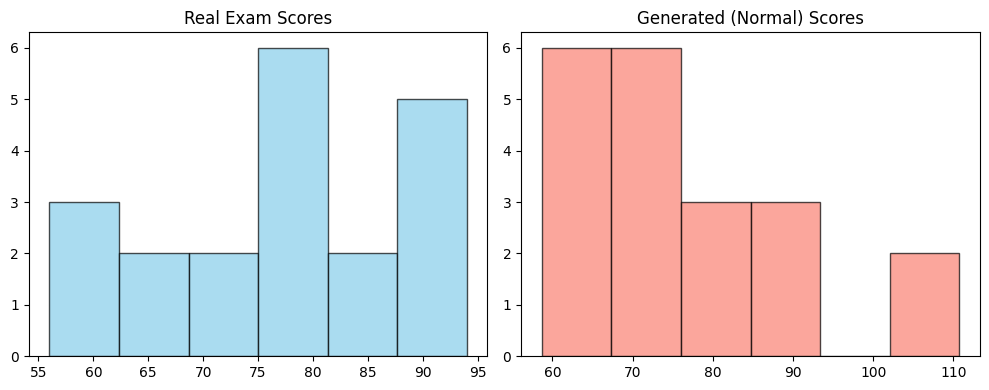

Estimated Probability (Score >= 75): 0.5634
Hypothesized Mean: 55
P-value: 0.0000
Conclusion: Reject H0

--- Solving Set A [7A2]: Customer Arrivals ---
Mean Arrivals: 11.45
Sample Variance: 6.68



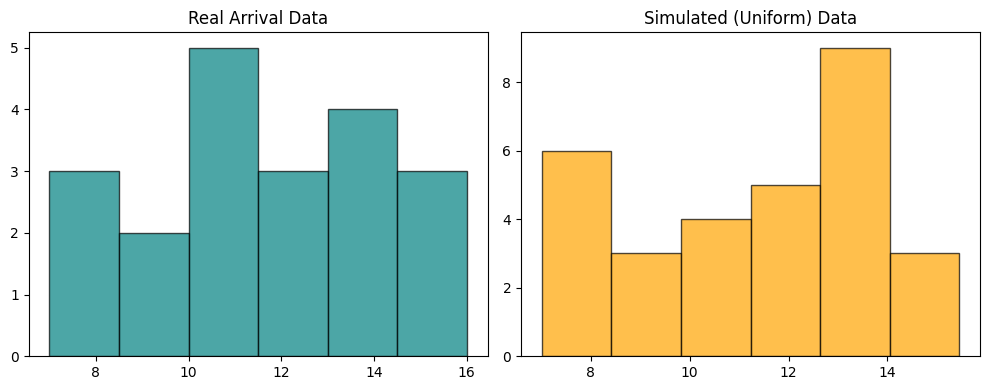

Probability of >15 customers: 0.1118
Hypothesized Mean: 15
T-statistic: -6.1419, P-value: 0.0000


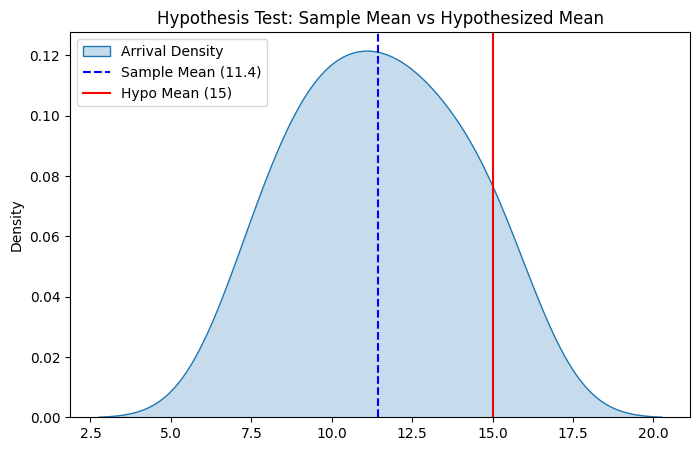

Result: Reject H0. The data does not support the hypothesized mean.


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

STUDENT_ID = 1055

def solve_set_7A1():
    print("--- Solving Set A [7A1]: Exam Scores ---")
    scores = np.array([93, 83, 69, 62, 75, 93, 73, 77, 65, 65, 78, 90, 94, 78, 57, 76, 56, 78, 84, 92])

    # 1. Basic Stats
    mean_val = np.mean(scores)
    pop_var = np.var(scores)
    sam_var = np.var(scores, ddof=1)
    std_dev = np.std(scores)

    print(f"Mean: {mean_val:.2f}")
    print(f"Population Variance: {pop_var:.2f}")
    print(f"Sample Variance (N-1): {sam_var:.2f}")
    print(f"Standard Deviation: {std_dev:.2f}\n")

    # 2. Random Number Generation
    generated_data = np.random.normal(mean_val, std_dev, 20)

    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.hist(scores, bins=6, color='skyblue', edgecolor='black', alpha=0.7)
    plt.title("Real Exam Scores")

    plt.subplot(1, 2, 2)
    plt.hist(generated_data, bins=6, color='salmon', edgecolor='black', alpha=0.7)
    plt.title("Generated (Normal) Scores")
    plt.tight_layout()
    plt.show()

    # 3. Monte Carlo Simulation
    samples = np.random.normal(mean_val, std_dev, 100000)
    prob = np.mean(samples >= 75)
    print(f"Estimated Probability (Score >= 75): {prob:.4f}")

    # 4. Hypothesis Testing
    hypo_mean = (STUDENT_ID % 50) + 50
    # FIX: The correct function name is ttest_1samp
    t_stat, p_val = stats.ttest_1samp(scores, hypo_mean)

    print(f"Hypothesized Mean: {hypo_mean}")
    print(f"P-value: {p_val:.4f}")
    conclusion = "Reject H0" if p_val < 0.05 else "Fail to Reject H0"
    print(f"Conclusion: {conclusion}\n")

def solve_set_7A2():
    print("--- Solving Set A [7A2]: Customer Arrivals ---")
    arrivals = np.array([8, 12, 10, 15, 9, 13, 11, 14, 7, 16, 10, 12, 9, 15, 11, 13, 14, 8, 12, 10])

    # 1. Basic Stats
    mean_arr = np.mean(arrivals)
    sam_var = np.var(arrivals, ddof=1)
    std_arr = np.std(arrivals)

    print(f"Mean Arrivals: {mean_arr:.2f}")
    print(f"Sample Variance: {sam_var:.2f}\n")

    # 2. Random Number Generation (Uniform)
    low, high = np.min(arrivals), np.max(arrivals)
    sim_data = np.random.uniform(low, high, 30)

    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.hist(arrivals, bins=6, color='teal', edgecolor='black', alpha=0.7)
    plt.title("Real Arrival Data")

    plt.subplot(1, 2, 2)
    plt.hist(sim_data, bins=6, color='orange', edgecolor='black', alpha=0.7)
    plt.title("Simulated (Uniform) Data")
    plt.tight_layout()
    plt.show()

    # 3. Monte Carlo Simulation
    mc_samples = np.random.uniform(low, high, 100000)
    prob_gt_15 = np.mean(mc_samples > 15)
    print(f"Probability of >15 customers: {prob_gt_15:.4f}")

    # 4. Hypothesis Testing
    hypo_mean = (STUDENT_ID % 10) + 10
    t_stat, p_val = stats.ttest_1samp(arrivals, hypo_mean)

    print(f"Hypothesized Mean: {hypo_mean}")
    print(f"T-statistic: {t_stat:.4f}, P-value: {p_val:.4f}")

    # Visualization for Hypothesis
    plt.figure(figsize=(8, 5))
    sns.kdeplot(arrivals, fill=True, label="Arrival Density")
    plt.axvline(mean_arr, color='blue', linestyle='--', label=f'Sample Mean ({mean_arr:.1f})')
    plt.axvline(hypo_mean, color='red', linestyle='-', label=f'Hypo Mean ({hypo_mean})')
    plt.title("Hypothesis Test: Sample Mean vs Hypothesized Mean")
    plt.legend()
    plt.show()

    conclusion = "Reject H0" if p_val < 0.05 else "Fail to Reject H0"
    print(f"Result: {conclusion}. The data {'does not support' if p_val < 0.05 else 'supports'} the hypothesized mean.")

# Execution
if __name__ == "__main__":
    solve_set_7A1()
    solve_set_7A2()